In [1]:
from helpers import build_main_teltarg_table, plot_pointing_offsets
from matplotlib import pyplot as plt

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from astroquery.eso import Eso
from astropy import table

In [2]:
eso = Eso()
eso.ROW_LIMIT = 1
collection_name_all = eso.list_surveys()
collection_name_all = collection_name_all
p3orig_all = []
for collection_name in collection_name_all:
    p3orig_all.extend(eso.query_surveys(collection_name, columns=["p3orig"])[0])
collections_info = table.Table([collection_name_all, p3orig_all], names=["collection_name", "p3orig"])

CRIRESplus: IDP
main_teltarg_table_CRIRESplus.fits already exists, overwriting.


Resolving SIMBAD coordinates: 100%|██████████| 28/28 [00:04<00:00,  6.33it/s]


ERIS-NIX: IDP
main_teltarg_table_ERIS-NIX.fits already exists, overwriting.


Resolving SIMBAD coordinates: 100%|██████████| 22/22 [00:02<00:00,  8.45it/s]


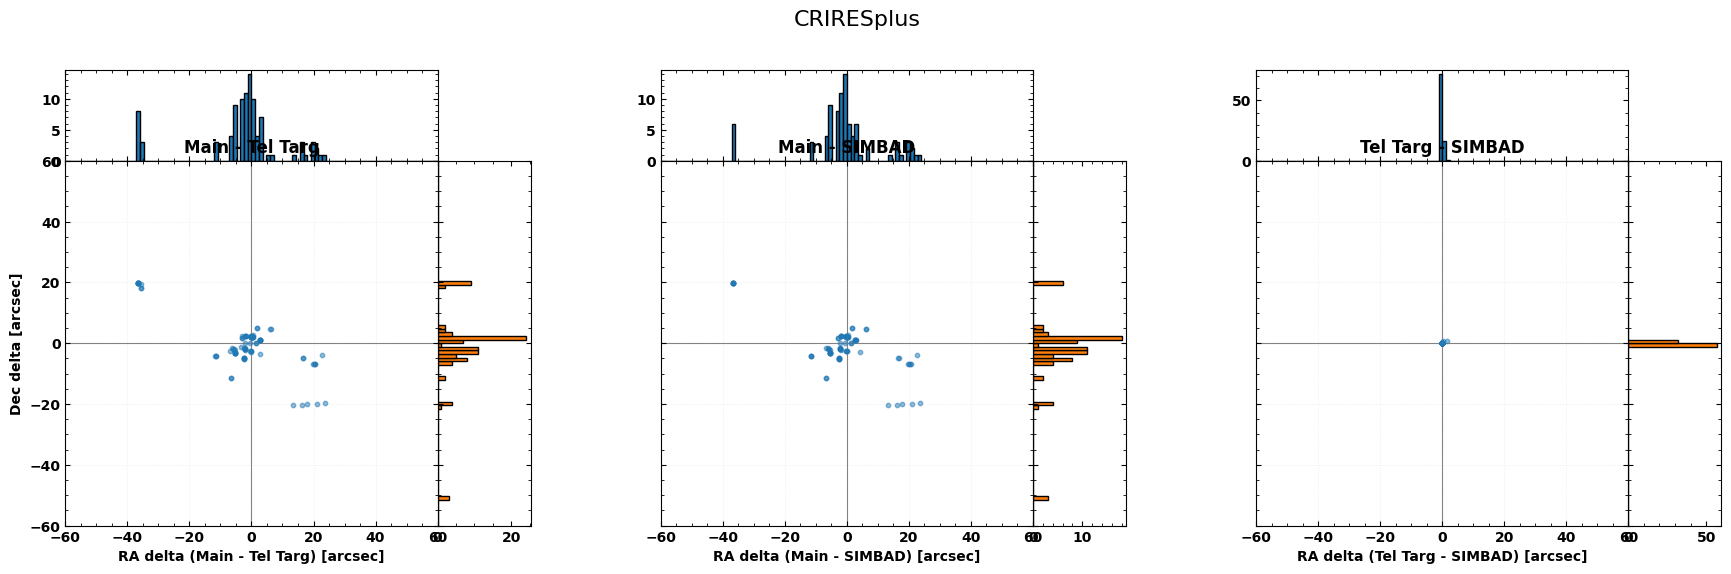

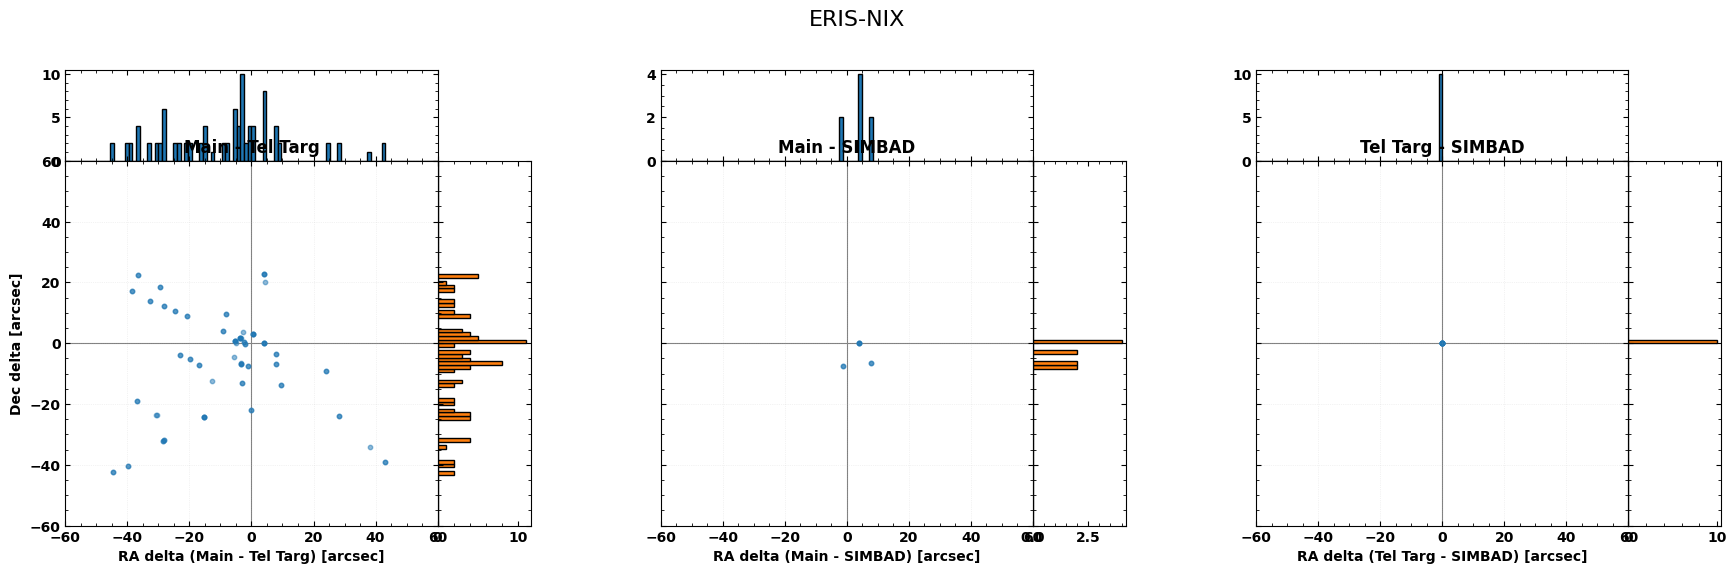

In [3]:
for collection_name, p3orig in collections_info[collections_info["p3orig"] == "IDP"][:2]:
    print(f"{collection_name}: {p3orig}")
    final_table, N = build_main_teltarg_table(collection_name, maxrec=100, max_workers=10, overwrite=True)
    fig, outfile = plot_pointing_offsets(final_table, collection_name=collection_name, p3orig=p3orig)
# plt.close('all')